In [1]:
from pandas import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [2]:
df = read_excel(r"C:\Users\sruti\Desktop\E-Commerce Sales Analysis\DATA SETS\Cleaned_Superstore_data.xlsx")
df.head()

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID',
       'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code',
       'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

Sales Distribution (Histogram)

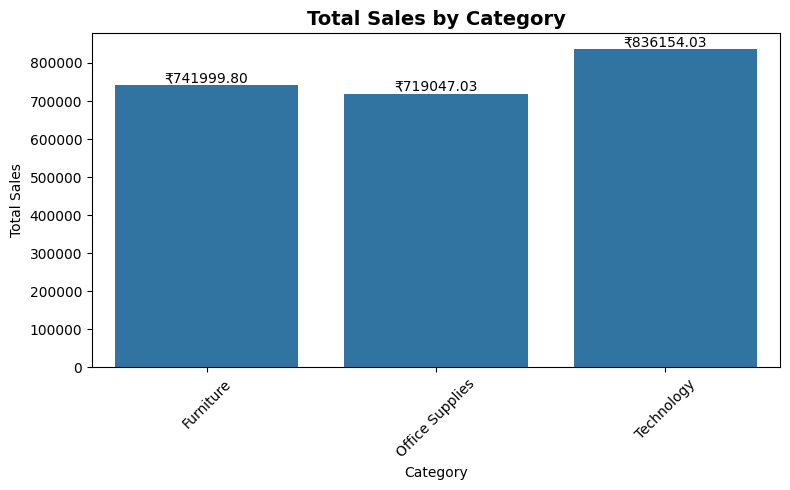

In [4]:
sales_by_category = df.groupby("Category")["Sales"].sum().reset_index()
plt.figure(figsize=(8,5))
ax = sns.barplot(data=sales_by_category,x="Category",y="Sales")
plt.title("Total Sales by Category", fontsize=14, fontweight="bold")
ax.bar_label(ax.containers[0], fmt="₹%.2f", fontsize=10, color="black", label_type="edge")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Profit Distribution

C:\Users\sruti\AppData\Local\Temp\ipykernel_4620\501879199.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Category",y="Profit",estimator="sum",errorbar=None,palette="viridis")


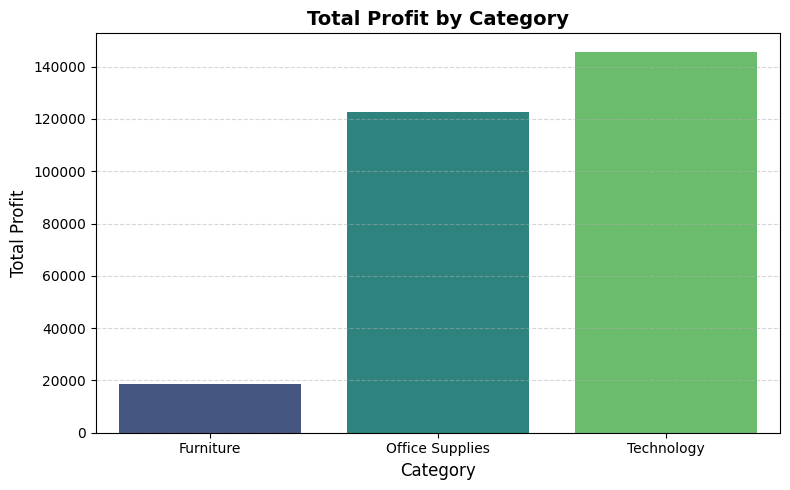

In [5]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df,x="Category",y="Profit",estimator="sum",errorbar=None,palette="viridis")
plt.title("Total Profit by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Sales By Category

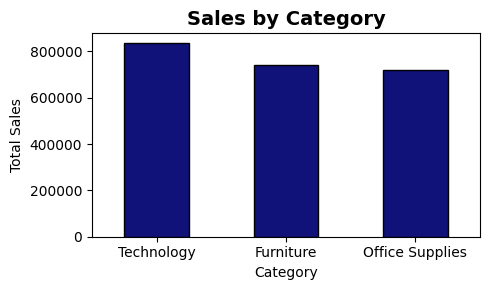

In [6]:
category_sales = (df.groupby("Category")["Sales"].sum().reset_index(name="Sales").sort_values(by="Sales", ascending=False))
plt.figure(figsize=(5, 3))
sns.barplot(data=category_sales, x="Category", y="Sales", width=0.5, color="darkblue", edgecolor="black")
plt.title("Sales by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales By Category

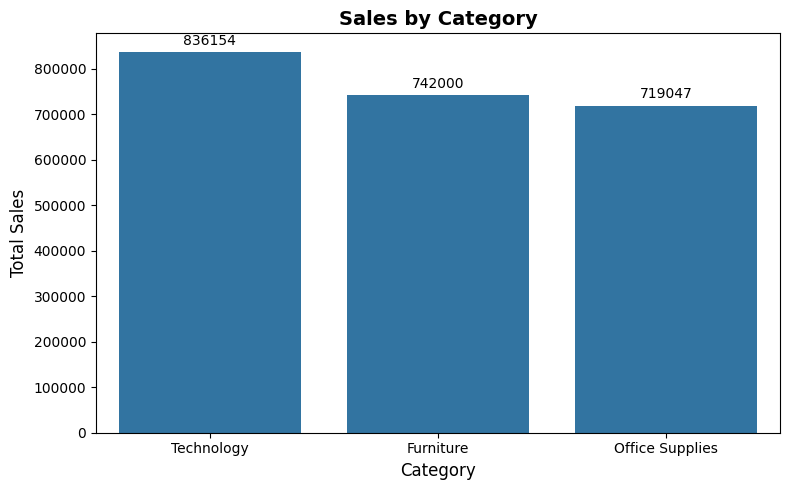

In [7]:
category_sales = (df.groupby("Category", as_index=False)["Sales"].sum().sort_values(by="Sales", ascending=False))
plt.figure(figsize=(8, 5)) 
ax = sns.barplot( data=category_sales, x="Category",y="Sales")

for container in ax.containers:ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Sales by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Profit By Category

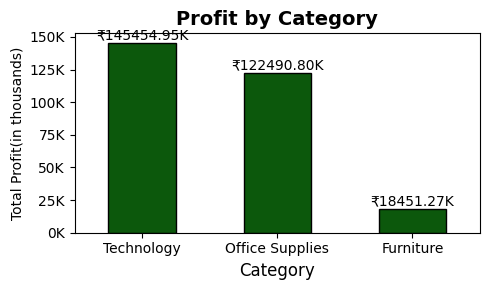

In [8]:
profit = (df.groupby("Category", as_index=False)["Profit"]
          .sum()
          .sort_values(by="Profit", ascending=False))
plt.figure(figsize=(5, 3))
ax = sns.barplot(data=profit,
                 x="Category",
                 y="Profit", 
                 width=0.5, color="darkgreen", edgecolor="black")
#for container in ax.containers:
#    labels = [f"₹{x/1000:.2f}K" for x in container.datavalues]
#    ax.bar_label(container, labels=labels, fontsize=10, padding=3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))    
ax.bar_label(ax.containers[0], fmt="₹%.2fK", fontsize=10, color="black", label_type="edge")    
plt.title("Profit by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Profit(in thousands)", fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 Products by sales

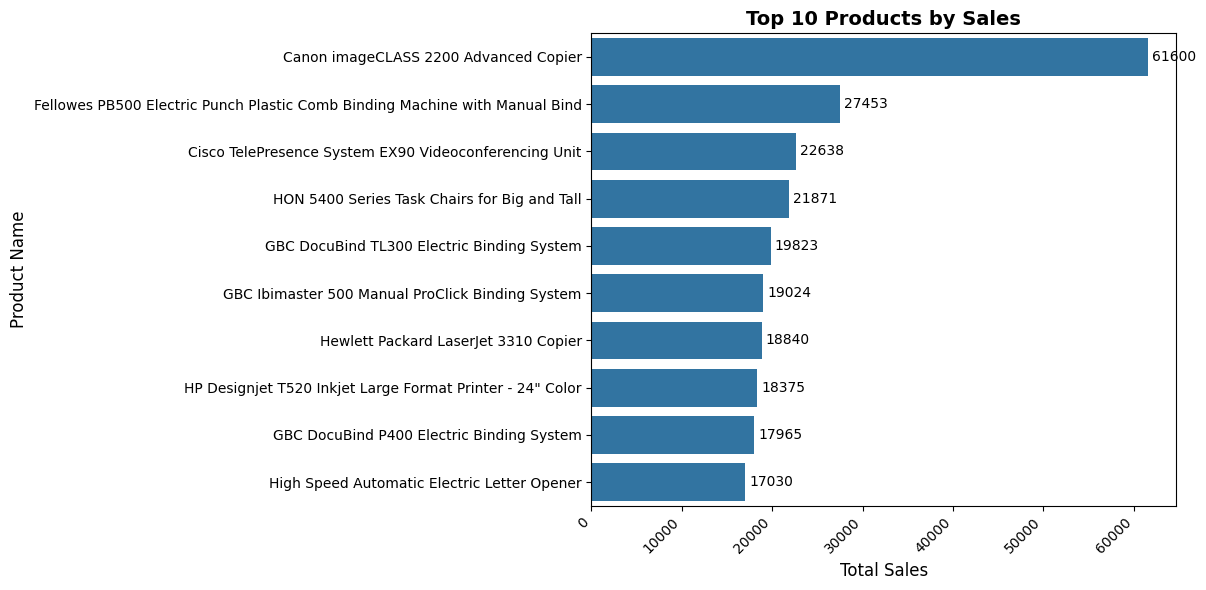

In [9]:
top_products = (df.groupby("Product_Name", as_index=False)["Sales"].sum().nlargest(10, "Sales"))
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_products,x="Sales",y="Product_Name")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Top 10 Customers

In [10]:
customers = (df.groupby("Customer Name", as_index=False)["Sales"].sum().nlargest(10, "Sales"))
plt.figure(figsize=(12, 6))
ax = sns.barplot( data=customers,x="Customer Name",y="Sales")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Top 10 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Customer Name", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

KeyError: 'Customer Name'

Sales by Region

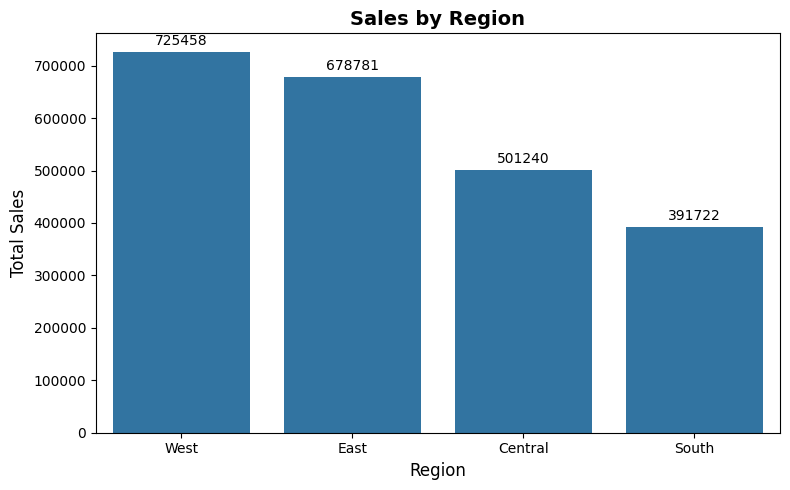

In [ ]:
region_sales = (df.groupby("Region")["Sales"].sum().reset_index(name="Sales").sort_values(by="Sales", ascending=False))
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=region_sales, x="Region", y="Sales")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.tight_layout()
plt.show()

Profit By Region

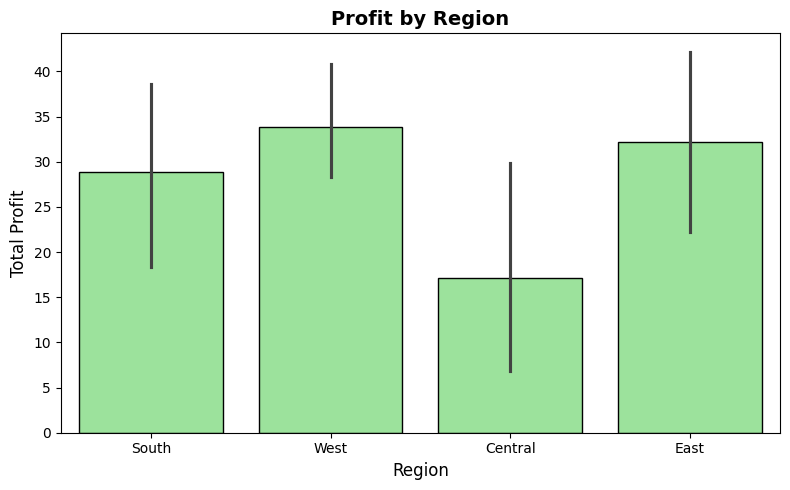

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x="Region",y="Profit",color="lightgreen", edgecolor="black")
plt.title("Profit by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)
plt.tight_layout()
plt.show()

Sales by Segment

C:\Users\sruti\AppData\Local\Temp\ipykernel_14520\1855012238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df,x="Region",y="Profit",estimator=sum,palette="Set2")


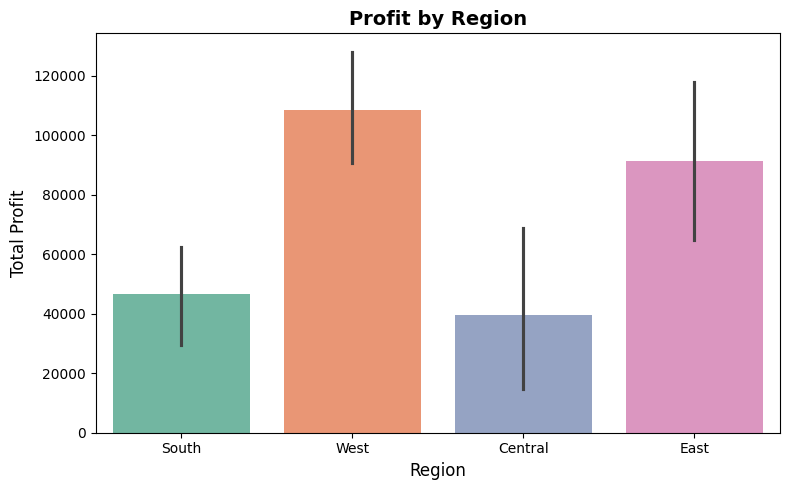

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df,x="Region",y="Profit",estimator=sum,palette="Set2")
plt.title("Profit by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)
plt.tight_layout()
plt.show()

Ship Mode Count

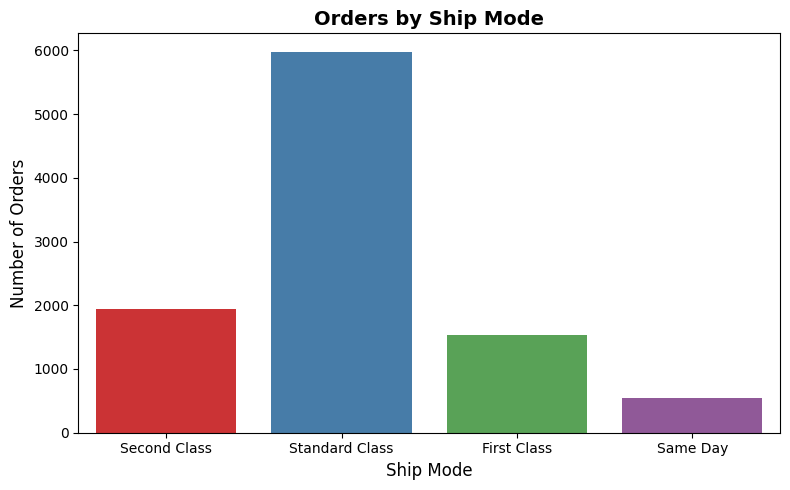

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df,x="Ship Mode",hue="Ship Mode",palette="Set1",legend=False)
plt.title("Orders by Ship Mode", fontsize=14, fontweight="bold")
plt.xlabel("Ship Mode", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.tight_layout()
plt.show()

Monthly sales Trend

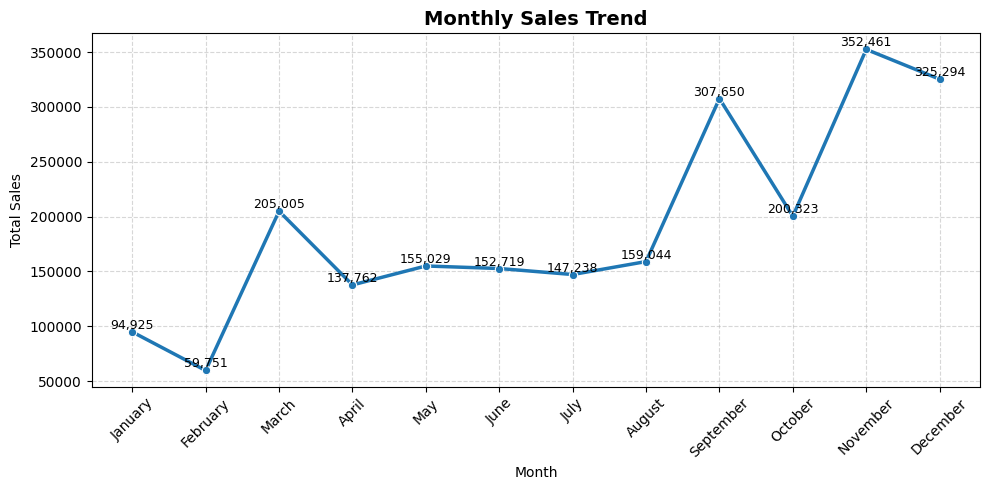

In [ ]:
month_order = [ "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
monthly_sales = (df.groupby(df["Order_Date"].dt.month_name())["Sales"].sum().reindex(month_order).reset_index(name="Sales"))

plt.figure(figsize=(10,5))
ax = sns.lineplot(data=monthly_sales,x="Order_Date",y="Sales",marker="o",linewidth=2.5)
for x, y in zip(monthly_sales["Order_Date"], monthly_sales["Sales"]):ax.text (x, y,f"{y:,.0f}",ha="center",va="bottom",fontsize=9)
plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Monthly profit Trend

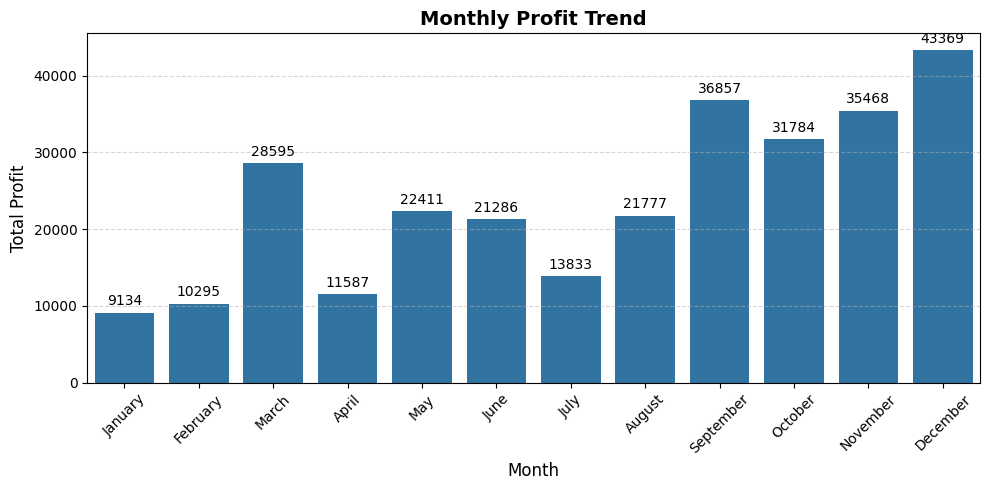

In [ ]:
monthly_profit = (df.groupby(df["Order_Date"].dt.month_name())["Profit"] .sum().reindex(month_order).reset_index(name="Profit"))
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
#monthly_profit["Order Date"] = pd.Categorical(monthly_profit["Order Date"],categories=month_order,ordered=True)
#monthly_profit = monthly_profit.sort_values("Order Date")
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=monthly_profit,x="Order_Date",y="Profit")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Monthly Profit Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Correlation Heatmap

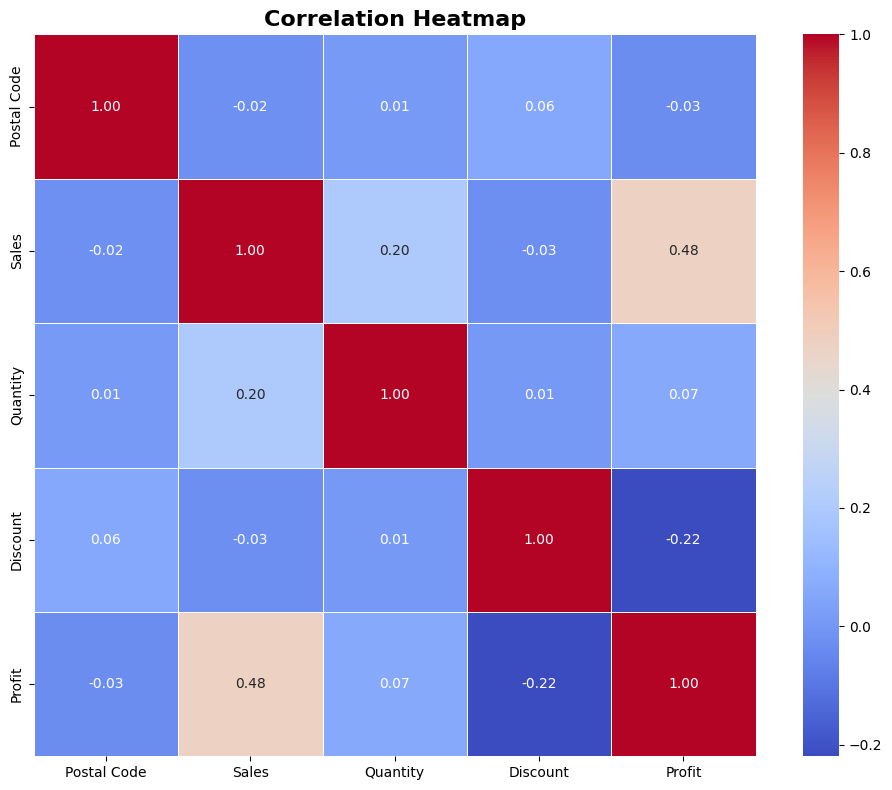

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,linecolor="white",square=True,cbar=True)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Sales Vs Profit

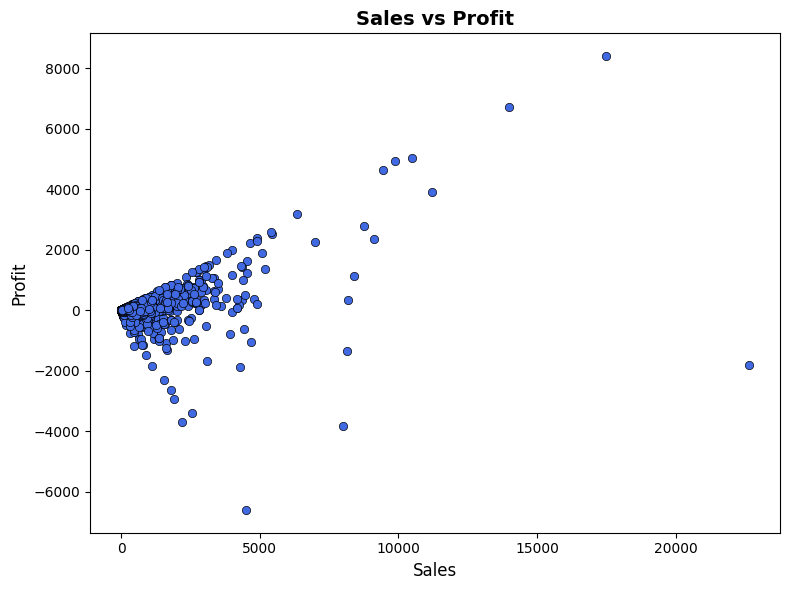

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df,x="Sales",y="Profit",color="royalblue",edgecolor="black")
plt.title("Sales vs Profit", fontsize=14, fontweight="bold")
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Profit", fontsize=12)
plt.tight_layout()
plt.show()

Discount Vs Profit

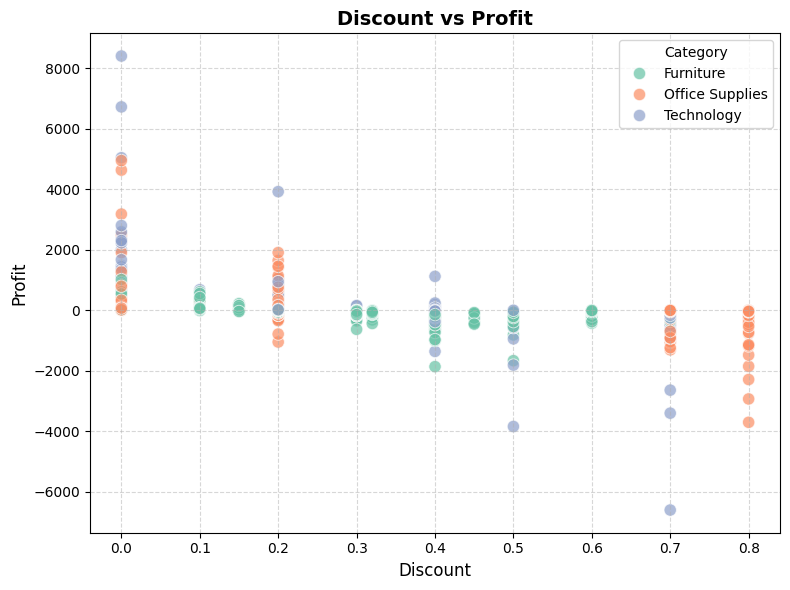

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df,x="Discount",y="Profit",hue="Category",palette="Set2",s=80,alpha=0.7)
plt.title("Discount vs Profit", fontsize=14, fontweight="bold")
plt.xlabel("Discount", fontsize=12)
plt.ylabel("Profit", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Sales Vs Box Plot

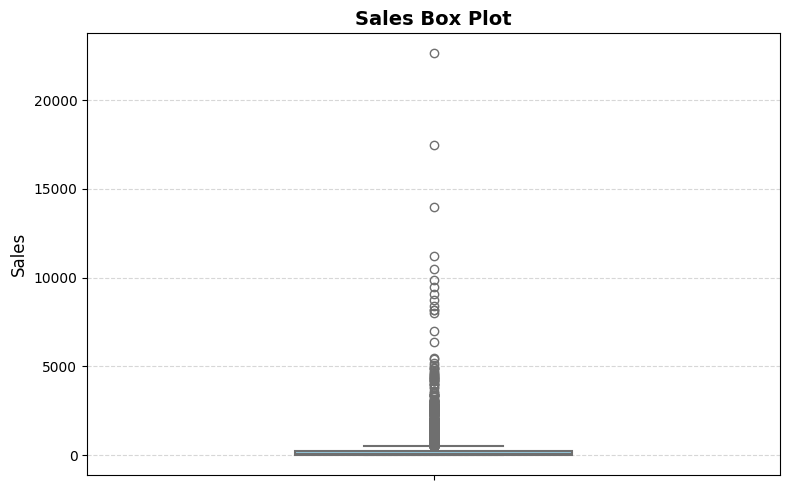

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=df,y="Sales",color="skyblue",width=0.4,linewidth=1.5)
plt.title("Sales Box Plot", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Profit Box Plot

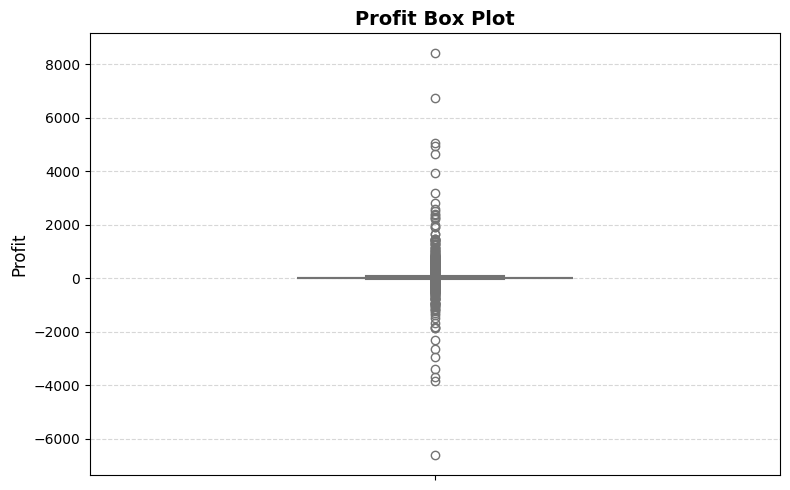

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=df,y="Profit",color="lightgreen",width=0.4,linewidth=1.5)
plt.title("Profit Box Plot", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Profit", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

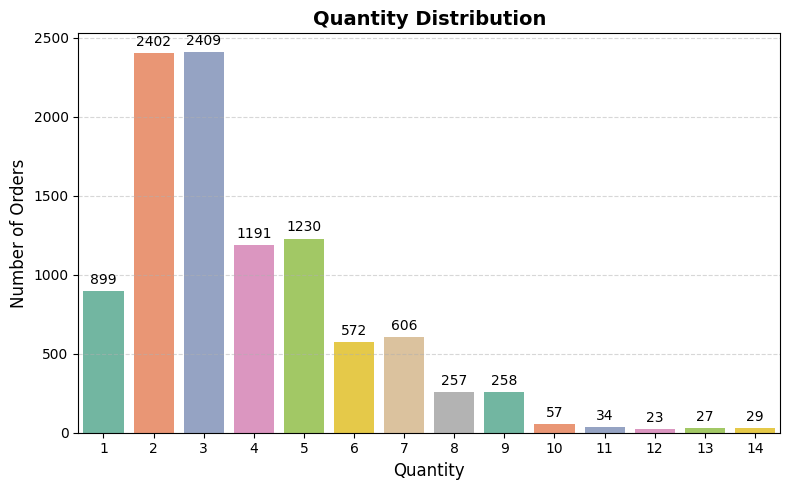

In [ ]:
quantity_dist = (df["Quantity"].value_counts().sort_index().reset_index())
quantity_dist.columns = ["Quantity", "Count"]
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=quantity_dist,x="Quantity",y="Count",hue="Quantity",palette="Set2",legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.title("Quantity Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Quantity", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Top 10 states by sales

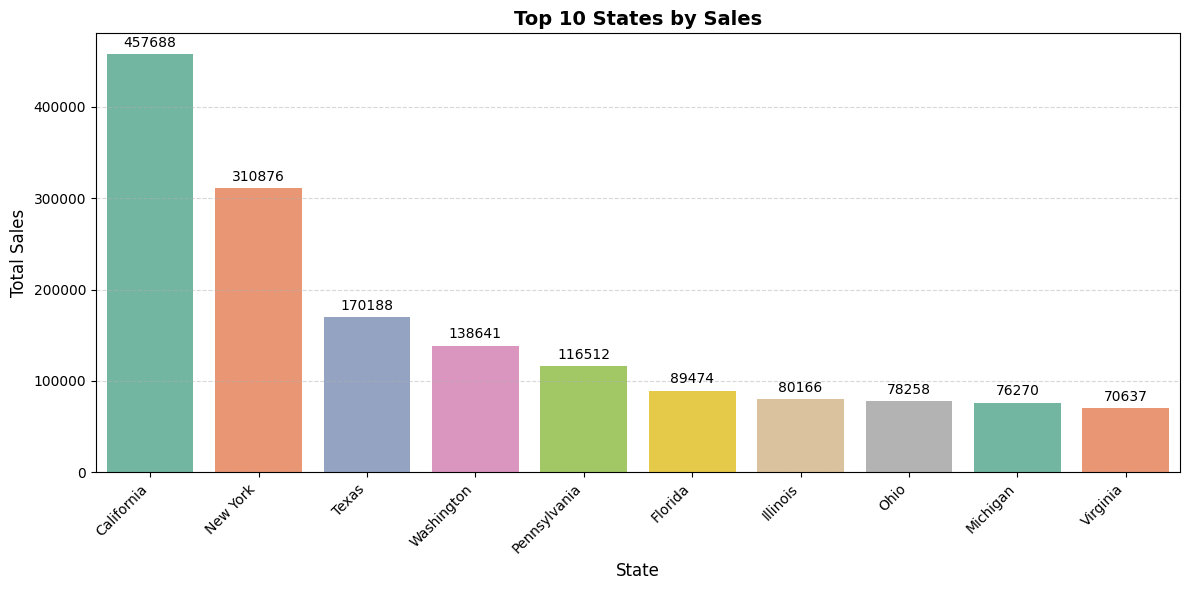

In [ ]:
states = (df.groupby("State")["Sales"] .sum() .nlargest(10, "Sales"))
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=states,x="State",y="Sales",hue="State",palette="Set2",legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Top 10 States by Sales", fontsize=14, fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()